SVM is a supervised learning algorithm used for classifying data.
It is used for both linear and non linear classification.
Used for regression problem.
Used for Outlier detection task.

Applications:
~Sentimental Analysis
~Image Classification and Recognition
~Hand Written Identification
~Face detection
~Anomaly detection
~Gene Expression Analysis

SVM Linear is a 2D surface ,a straight line that classifies data points,
Also called as Maximum Margin Linear Classifier - Setting maximum margin
It ensures that the margin between the closest data points of different classes(each closest data points is known as support vectors) is maximized.


SVM Non Linear -Hyper plane.The dimenesion of the hyperplene depeneds on the number of features.In non linear SVM ,there can be multiple planes or dicision boundaries to seggregate the classes in n-dimensional space - We need to find the best decision boundary that helps to best data plane
This best boundary is known as the hyperplane.Simply SVM is a machine learning algorithm to find hyperplane in n-dimensional space that disctinctly classify the data points
When Outliers are there- need to mis =classify or ignore it
If we consider outlier - minimum margin-wrong prediction

SoftMargin Formulation:
It allows SVM to make certain number of mistakes and keeps margins as wide as possible.so that other data points can still be classify correctly

How to perform misclassifications?
1. Misclassification penalty - C
With the help of a hyperparameter called c-parameter.It tells the SVM,how much you want to avoid misclassifying in each training.When you increase the value of C parameter - minimum margin set.When you decrease the value of C paramter - maximum margin set

Errors in SVM:
Classification Error(A)
Margin Error(B)
Svm Goal = Min(CA+B)

In [50]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import numpy as np


In [22]:
X,y=make_classification(n_samples=1000,n_features=2,n_informative=2,n_redundant=0,random_state=42)
X

array([[-0.99910178, -0.66386   ],
       [ 1.24668618,  1.15359685],
       [ 0.96277683,  0.85939747],
       ...,
       [-0.10126746, -1.59017563],
       [ 0.64376105, -0.78053855],
       [ 0.69852984, -1.27940455]])

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=.8,random_state=42)

In [8]:
model=SVC(kernel='linear')

In [9]:
model.fit(X_train,y_train)

SVC(kernel='linear')

In [10]:
y_pred=model.predict(X_test)

In [12]:
accuracy_score(y_test,y_pred)

0.88

In [26]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       101
           1       0.88      0.88      0.88        99

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200



In [25]:
n=model.predict([[21,21]])
n

array([1])

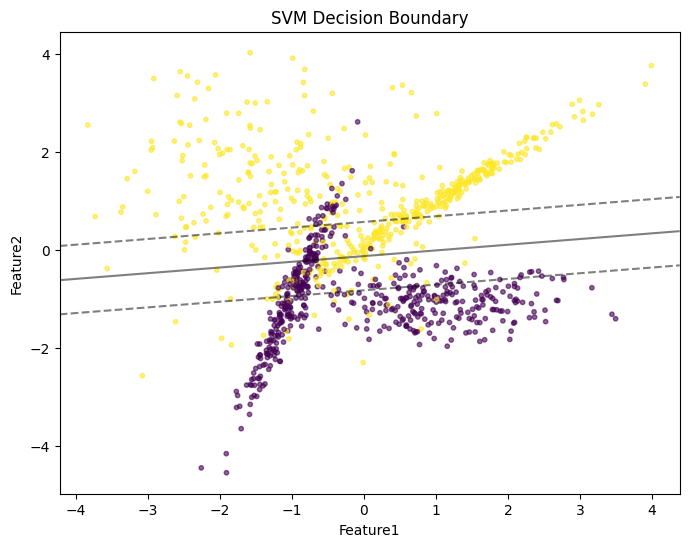

In [116]:
#ploting the Decision Boundry
# X[:,:]=every row every column
# X[3:3]=3rd row,3rd column
# X[:,3]=Every row and 3rd col
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',s=10,alpha=.6)
ax=plt.gca()
xlimit=ax.get_xlim()
ylimit=ax.get_ylim()
xx,yy=np.meshgrid(np.linspace(xlimit[0],xlimit[1],100),np.linspace(ylimit[0],ylimit[1],100))
z=model.decision_function(np.c_[xx.ravel(),yy.ravel()])#ravel is for flattening 2d array to 1d
z=z.reshape(xx.shape)
# plt.contourf(xx,yy,z,levels=[-1,0,1],alpha=.5,cmap='viridis',linestyles=['--','-','--'])
plt.contour(xx,yy,z,colors='k',levels=[-1,0,1],alpha=.5,linestyles=['--','-','--'])

plt.title('SVM Decision Boundary')
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

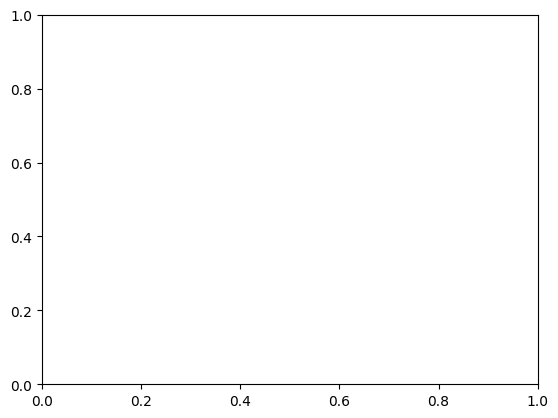

In [60]:
ax=plt.gca()
xlimit=ax.get_xlim()
ylimit=ax.get_ylim()
xx,yy=np.meshgrid(np.linspace(xlimit[0],xlimit[1],100),np.linspace(ylimit[0],ylimit[1],100))#
